In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Red filter

Quadratic fit: Δm = -0.004030541407159276x^4 + 0.01385068599032001x^3 + 0.06818635143214674x^2 + -0.407326277191949x + -0.012633524964969965


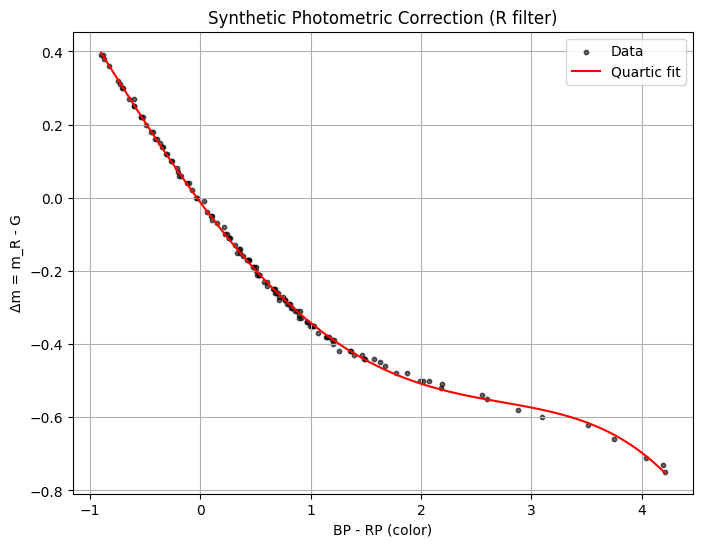

In [3]:
file_path = "/mnt/c/Users/catal/Downloads/Pickles_CVM_all.csv"  # change if needed
df = pd.read_csv(file_path)

# Color (BP - RP)
df["color"] = df["GAIA_GAIA3.Gbp.res"] - df["GAIA_GAIA3.Grp.res"]


#  Choose filter (Case: R filter)
df["delta_R"] = df["CVM_IMX224_R.res"] - df["GAIA_GAIA3.G.res"]

# Remove NaN values
df_clean = df.dropna(subset=["color", "delta_R"])

#  Plot
plt.figure(figsize=(8,6))
plt.scatter(df_clean["color"], df_clean["delta_R"], color='black', s=10, alpha=0.6, label="Data")

coeffs = np.polyfit(df_clean["color"], df_clean["delta_R"], 4)

a, b, c, d, e = coeffs


x = np.linspace(df_clean["color"].min(), df_clean["color"].max(), 100)
y = a*x**4 + b*x**3 + c*x**2 + d*x + e

print(f"Quadratic fit: Δm = {a}x^4 + {b}x^3 + {c}x^2 + {d}x + {e}")

plt.plot(x, y, color="red", label="Quartic fit")

plt.xlabel("BP - RP (color)")
plt.ylabel("Δm = m_R - G")
plt.title("Synthetic Photometric Correction (R filter)")
plt.legend()
plt.grid()
plt.show()

# Blue filter

Quartic fit: Δm = 0.009321930880512313x^4 + -0.04559028703693668x^3 + -0.05142060904859903x^2 + 0.11676990140326289x + 0.014177778451245857


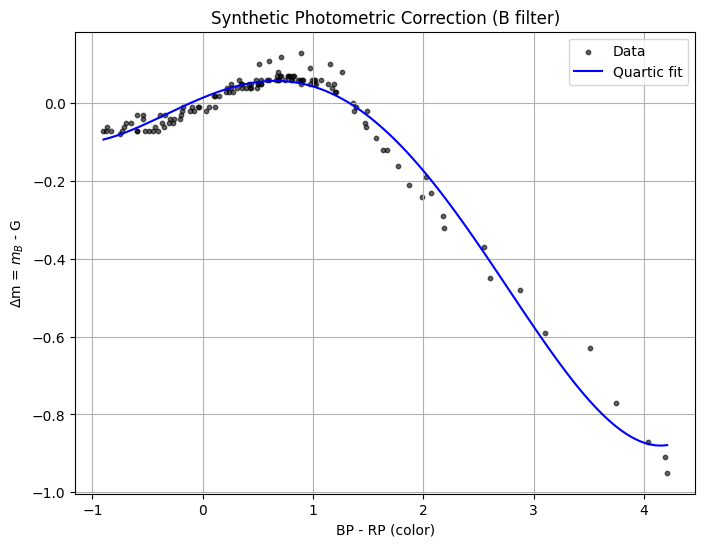

In [4]:
# Color (BP - RP)
df["color"] = df["GAIA_GAIA3.Gbp.res"] - df["GAIA_GAIA3.Grp.res"]


#  Choose filter (Case: B filter)
df["delta_B"] = df["CVM_IMX224_B.res"] - df["GAIA_GAIA3.G.res"]

# Remove NaN values
df_clean = df.dropna(subset=["color", "delta_B"])

#  Plot
plt.figure(figsize=(8,6))
plt.scatter(df_clean["color"], df_clean["delta_B"], color='black', s=10, alpha=0.6, label="Data")

coeffs = np.polyfit(df_clean["color"], df_clean["delta_B"], 4)

a, b, c, d, e = coeffs


x = np.linspace(df_clean["color"].min(), df_clean["color"].max(), 100)
y = a*x**4 + b*x**3 + c*x**2 + d*x + e
#y = a*x**3 + b*x**2 + c*x + d

print(f"Quartic fit: Δm = {a}x^4 + {b}x^3 + {c}x^2 + {d}x + {e}")

plt.plot(x, y, color="blue", label="Quartic fit")

plt.xlabel("BP - RP (color)")
plt.ylabel(r"Δm = $m_B$ - G")
plt.title("Synthetic Photometric Correction (B filter)")
plt.legend()
plt.grid()
plt.show()

# Green filter

Quartic fit: Δm = 0.0024108844227971383x^4 + -0.023410742570759275x^3 + 0.054889616964685896x^2 + -0.12330245692577392x + -0.030298475782780353


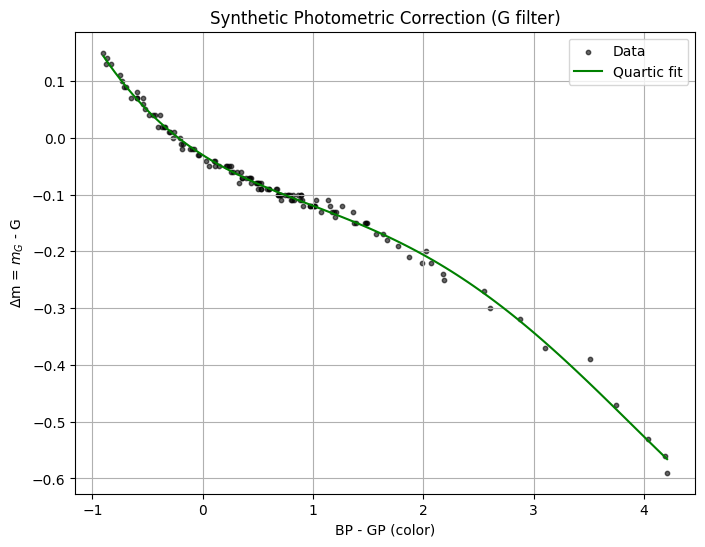

In [5]:
# Color (BP - RP)
df["color"] = df["GAIA_GAIA3.Gbp.res"] - df["GAIA_GAIA3.Grp.res"]


#  Choose filter (Case: G filter)
df["delta_G"] = df["CVM_IMX224_G.res"] - df["GAIA_GAIA3.G.res"]

# Remove NaN values
df_clean = df.dropna(subset=["color", "delta_G"])

#  Plot
plt.figure(figsize=(8,6))
plt.scatter(df_clean["color"], df_clean["delta_G"], color='black', s=10, alpha=0.6, label="Data")

coeffs = np.polyfit(df_clean["color"], df_clean["delta_G"], 4)

a, b, c, d, e = coeffs

x = np.linspace(df_clean["color"].min(), df_clean["color"].max(), 100)
y = a*x**4 + b*x**3 + c*x**2 + d*x + e

print(f"Quartic fit: Δm = {a}x^4 + {b}x^3 + {c}x^2 + {d}x + {e}")

plt.plot(x, y, color="green", label="Quartic fit")

plt.xlabel("BP - GP (color)")
plt.ylabel(r"Δm = $m_G$ - G")
plt.title("Synthetic Photometric Correction (G filter)")
plt.legend()
plt.grid()
plt.show()

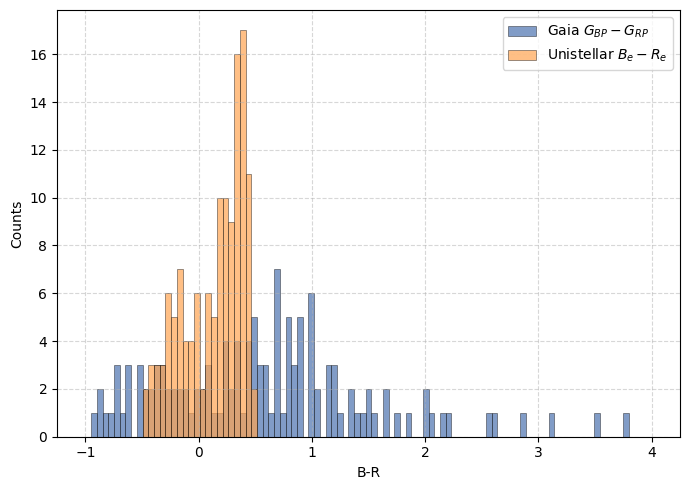

In [6]:
# Compute color indices
df["color_unistellar"] = df["CVM_IMX224_B.res"] - df["CVM_IMX224_R.res"]
df["color_gaia"] = df["GAIA_GAIA3.Gbp.res"] - df["GAIA_GAIA3.Grp.res"]

# Drop NaNs
df_clean = df.dropna(subset=["color_unistellar", "color_gaia"])

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

bins = np.linspace(-1, 4, 100)  # adjust range if needed

ax.hist(df_clean["color_gaia"],       bins=bins, color="#4C72B0", alpha=0.7, 
        edgecolor="black", linewidth=0.4, label="Gaia $G_{BP}-G_{RP}$")
ax.hist(df_clean["color_unistellar"], bins=bins, color="#FFA552", alpha=0.7, 
        edgecolor="black", linewidth=0.4, label="Unistellar $B_e-R_e$")

ax.set_xlabel("B-R")
ax.set_ylabel("Counts")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()